In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPool2D,Flatten,Dense,Dropout,Conv2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [65]:
classifier = Sequential()

classifier.add(Conv2D(128,(3,3),padding = 'same',input_shape = (100,100,3),activation='relu'))
classifier.add(MaxPool2D(pool_size = (2,2)))
classifier.add(Dropout(0.25))

classifier.add(Conv2D(64,(3,3),padding = 'same',activation='relu'))
classifier.add(MaxPool2D(pool_size=(2,2)))
classifier.add(Dropout(0.25))

classifier.add(Conv2D(32,(3,3),padding = 'same',activation='relu'))
classifier.add(MaxPool2D(pool_size = (2,2)))
classifier.add(Dropout(0.25))

classifier.add(Conv2D(16,(3,3),padding = 'same',activation='relu'))
classifier.add(MaxPool2D(pool_size = (2,2)))
classifier.add(Dropout(0.25))

classifier.add(Flatten())

In [66]:
# classifier.add(Dense(units=512,activation='relu'))
classifier.add(Dense(units=256,activation='relu'))
classifier.add(Dense(units=128,activation='relu'))
classifier.add(Dense(units=64,activation='relu'))
classifier.add(Dense(units=32,activation='relu'))
classifier.add(Dense(units=13,activation='softmax'))

In [67]:
classifier.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_54 (Conv2D)           (None, 100, 100, 128)     3584      
_________________________________________________________________
max_pooling2d_54 (MaxPooling (None, 50, 50, 128)       0         
_________________________________________________________________
dropout_54 (Dropout)         (None, 50, 50, 128)       0         
_________________________________________________________________
conv2d_55 (Conv2D)           (None, 50, 50, 64)        73792     
_________________________________________________________________
max_pooling2d_55 (MaxPooling (None, 25, 25, 64)        0         
_________________________________________________________________
dropout_55 (Dropout)         (None, 25, 25, 64)        0         
_________________________________________________________________
conv2d_56 (Conv2D)           (None, 25, 25, 32)      

In [68]:
from tensorflow.keras.optimizers import SGD,RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau

#created a checkpoint if model validation is constant
checkpoint = ModelCheckpoint('/home/dipak/Desktop/AiProjects/fruits/fruits/fruitmodel.h5',
                            monitor='val_loss',
                            mode = 'min',
                            save_best_only=True,
                            verbose=1)

# If validation loss is not improving early stop the model training
earlystopping = EarlyStopping(monitor='val_loss',
                             min_delta = 0.001,#changes after 3 digit are considered
                             patience = 3, #set epochs to check min_delta it check for 3 extra epochs,
                             verbose = 1,
                             restore_best_weights = True 
                             )
#This callback monitors a quantity and if no improvement is seen for a 'patience' number of epochs, the learning rate is reduced.
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',
                             factor = 0.1,
                             patience = 3, # until 3 additional epoches on reducing learning rate if no change is detected
                              #then selects that model
                             verbose= 1,
                             min_delta= 0.001)

callback = [checkpoint,earlystopping,reduce_lr]

#optimizer select best learning rate by selecting best gradient loss
classifier.compile(optimizer=RMSprop(lr = 0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# Test Train Split

In [69]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.3,
                                   rotation_range = 30, #if data is less reduce this and use this if flip is needed like in mnsit dataset
                                   width_shift_range = 0.3,
                                   height_shift_range= 0.3,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   #fill_mode = 'nearest' # nearest corresponding features are 
                                  )

test_datagen = ImageDataGenerator(rescale=1./255)
#                                   shear_range = 0.3,
#                                    zoom_range = 0.2,
#                                    horizontal_flip = True)

training_set = train_datagen.flow_from_directory('/home/dipak/Desktop/AiProjects/fruits/fruits/Training/',
                                                target_size= (100,100),
                                                batch_size=64,
                                                class_mode='categorical')


Found 6729 images belonging to 13 classes.


In [70]:
test_set = test_datagen.flow_from_directory('/home/dipak/Desktop/AiProjects/fruits/fruits/Test/',
                                                target_size= (100,100),
                                                batch_size=64,
                                                class_mode='categorical')

Found 2257 images belonging to 13 classes.


# Fit Model

In [1]:
batch_size = 64
history = classifier.fit(training_set,
                         steps_per_epoch = 6729//batch_size, 
                         epochs = 15,
                         callbacks = callback,
                         validation_data = test_set,
                         validation_steps = 2257//batch_size 
                        )

NameError: name 'classifier' is not defined

# Confusion Matrix

Confusion Matrix
[[ 0  0  0  4  1  2  9  9  0  1]
 [ 3  0  0  3  3  1  7 10  0  1]
 [ 4  0  0  8  0  2  5  7  0  1]
 [ 3  0  0  3  2  2  9  9  2  0]
 [ 7  1  0  1  1  1  3  9  2  1]
 [ 3  0  0  4  0  1  2 14  1  3]
 [ 6  0  1  3  1  1  3  9  2  0]
 [ 2  0  0  5  0  0  9 11  0  1]
 [ 2  2  0  2  1  2  9  9  0  0]
 [ 3  0  0  1  1  1  4 13  3  0]]
Confusion Matrix Heatmap


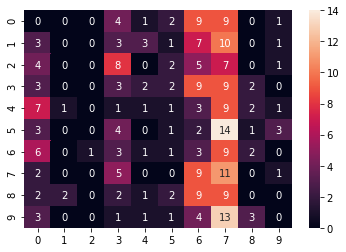

In [37]:
from sklearn.metrics import classification_report,confusion_matrix
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

class_label = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'A',7:'B',8:'C',9:'D',10:'E'}
y_pred = classifier.predict(test_set,272//batch_size +1)
y_pred = np.argmax(y_pred,axis = 1)

print("Confusion Matrix")
reasult = confusion_matrix(test_set.classes,y_pred)
print(reasult)

print("Confusion Matrix Heatmap")
import seaborn as sns
sns.heatmap(reasult, annot=True)

[]

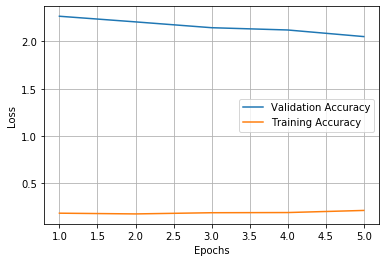

In [34]:
# Accuracy Plot
import matplotlib.pyplot as plt

history_dic = history.history #keyword and object
acc_value = history_dic['accuracy'] #from training epochs
val_acc_value = history_dic['val_accuracy']

epochs = range(1, len(acc_value)+1)

line1 = plt.plot(epochs,val_loss_value,label = 'Validation Accuracy')
line2 = plt.plot(epochs,acc_value,label = 'Training Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.plot()